# Explicabilitat global i local dels models amb SHAP

Aquest notebook analitza el comportament del sistema d'entrenament jeràrquic V3 utilitzant la llibreria **SHAP (SHapley Additive exPlanations)**.

Dividim l'estudi en dues parts:
1. **Estat 1 (Crònic vs NO):** Explicació del model `RandomForestClassifier` que determina si un pacient és crònic.
2. **Estat 2 (PCC vs MACA):** Explicació del model `HistGradientBoostingClassifier` calibrat que separa PCC de MACA entre els pacients prèviament identificats com a crònics.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Inicialitzar entorn de visualització de SHAP
shap.initjs()

ImportError: DLL load failed while importing _dispatcher: Una directiva de Control de aplicaciones bloqueó este archivo.

In [3]:
DATA_PATH = "../data/processed/dataset_final_pcc.csv"
MODEL_S1_PATH = "models/model_stage1_v3.joblib"
MODEL_S2_PATH = "models/model_stage2_v3.joblib"

# Carregar dades
df = pd.read_csv(DATA_PATH)
print(f"Dataset carregat: {df.shape[0]} pacients, {df.shape[1]} columnes.")

# Carregar models
model_s1 = joblib.load(MODEL_S1_PATH)
model_s2 = joblib.load(MODEL_S2_PATH)
print("Models carregats correctament.")

Dataset carregat: 37902 pacients, 107 columnes.
Models carregats correctament.


In [4]:
# Preparar dades originals per a la transformació
drop_cols = ["id_pacient", "target", "cronic"]
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Obtenir el preprocessador del pipeline
preprocessor = model_s1.named_steps["preprocessor"]

# Transformar les dades
X_trans = preprocessor.transform(X_all)

# Obtenir els noms de les columnes finals (One-Hot inclòs)
feature_names = preprocessor.get_feature_names_out()
# Netejar prefixos de scikit-learn ('num__' i 'cat__')
feature_names_clean = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

# Crear un DataFrame amb les dades transformades i noms de columnes correctes
X_trans_df = pd.DataFrame(X_trans, columns=feature_names_clean)
print(f"Dades preprocessades: {X_trans_df.shape[0]} files, {X_trans_df.shape[1]} columnes transformades.")

Dades preprocessades: 37902 files, 109 columnes transformades.


## 1. Explicabilitat de l'Estat 1 (Crònic vs NO)
Analitzem el model de bosc aleatori (`RandomForestClassifier`) que classifica si un pacient té alguna malaltia crònica.

In [5]:
# Inicialitzem l'explicador d'arbres per al RandomForest
classifier_s1 = model_s1.named_steps["classifier"]
explainer_s1 = shap.TreeExplainer(classifier_s1)

# Agafem una mostra aleatòria de 1000 pacients per accelerar els gràfics
sample_indices = np.random.choice(X_trans_df.index, size=1000, replace=False)
X_sample = X_trans_df.loc[sample_indices]

# Calcular SHAP values per la mostra
shap_values_s1 = explainer_s1.shap_values(X_sample)

# Per a bosc aleatori binari, shap_values_s1 és una llista: [shap_values_classe_0, shap_values_classe_1]
# Ens interessa la classe 1 (Crònic)
if isinstance(shap_values_s1, list):
    shap_values_s1_chronic = shap_values_s1[1]
else:
    shap_values_s1_chronic = shap_values_s1[:, :, 1] if len(shap_values_s1.shape) == 3 else shap_values_s1

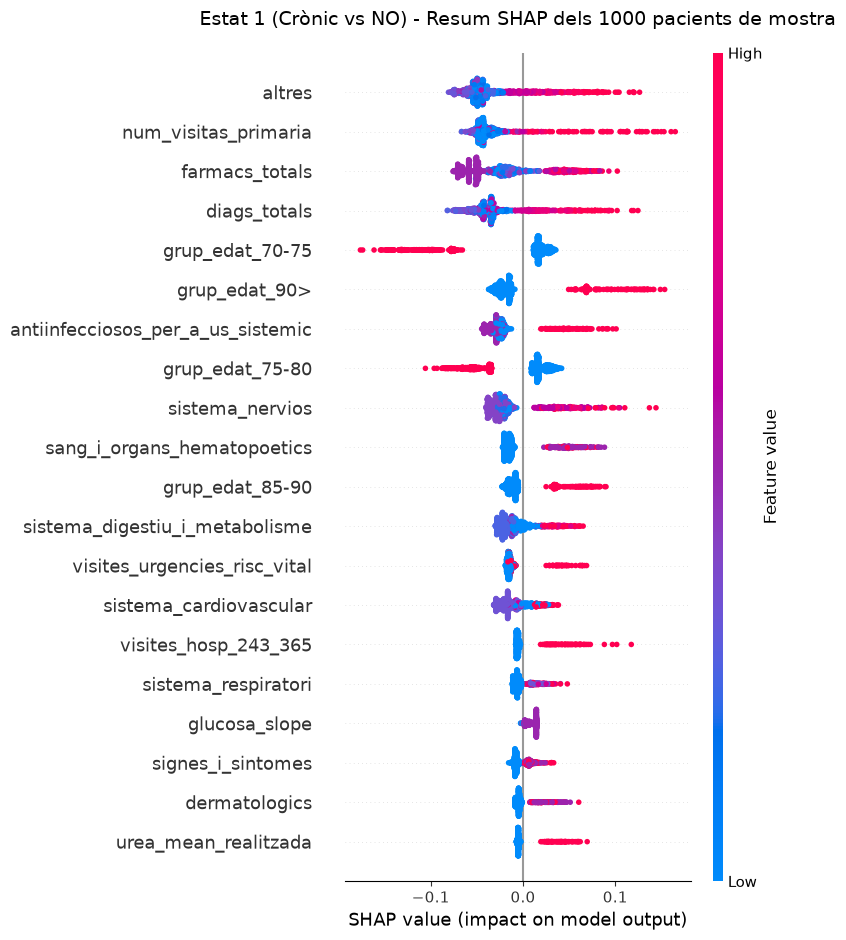

In [6]:
# Gràfic de resum global (Beeswarm) de l'Estat 1
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_s1_chronic, X_sample, show=False)
plt.title("Estat 1 (Crònic vs NO) - Resum SHAP dels 1000 pacients de mostra", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Explicant pacient amb índex original 1495:


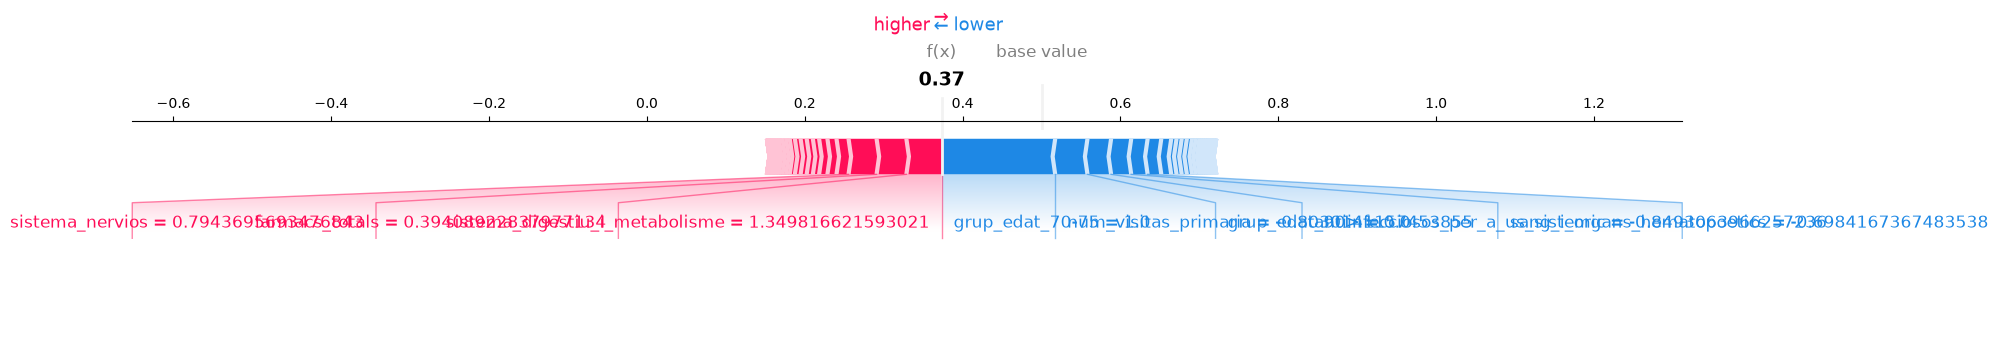

In [7]:
# Explicació local per a un pacient específic de mostra (Force Plot)
pacient_idx = sample_indices[0]
print(f"Explicant pacient amb índex original {pacient_idx}:")

# Gràfic de força
shap.force_plot(
    explainer_s1.expected_value[1],
    shap_values_s1_chronic[0],
    X_sample.iloc[0],
    matplotlib=True
)
plt.show()

## 2. Explicabilitat de l'Estat 2 (PCC vs MACA)
Analitzem el model de Gradient Boosting (`HistGradientBoostingClassifier`) que s'aplica sobre els pacients ja considerats crònics per diferenciar entre complexos (PCC) i avançats (MACA).

In [8]:
# Filtrem només els pacients crònics reals per explicar l'Estat 2
df_chronic = df[df["target"] > 0].copy()
X_chronic = df_chronic.drop(columns=[c for c in drop_cols if c in df_chronic.columns]).copy()

# Transformem els crònics amb el preprocessador
X_trans_chronic = preprocessor.transform(X_chronic)
X_trans_chronic_df = pd.DataFrame(X_trans_chronic, columns=feature_names_clean)

# Obtenir el classificador HistGradientBoostingClassifier de dins del CalibratedClassifierCV
classifier_s2 = model_s2.named_steps["classifier"].calibrated_classifiers_[0].estimator
explainer_s2 = shap.TreeExplainer(classifier_s2)

# Agafem una mostra de 500 pacients crònics
sample_indices_c = np.random.choice(X_trans_chronic_df.index, size=min(500, len(X_trans_chronic_df)), replace=False)
X_sample_c = X_trans_chronic_df.loc[sample_indices_c]

# Calcular SHAP values
shap_values_s2 = explainer_s2.shap_values(X_sample_c)

# HistGradientBoosting binary retorna un array 2D de shap values directament per a la classe positiva (MACA)
if isinstance(shap_values_s2, list):
    shap_values_s2_maca = shap_values_s2[1]
elif len(shap_values_s2.shape) == 3:
    shap_values_s2_maca = shap_values_s2[:, :, 1]
else:
    shap_values_s2_maca = shap_values_s2

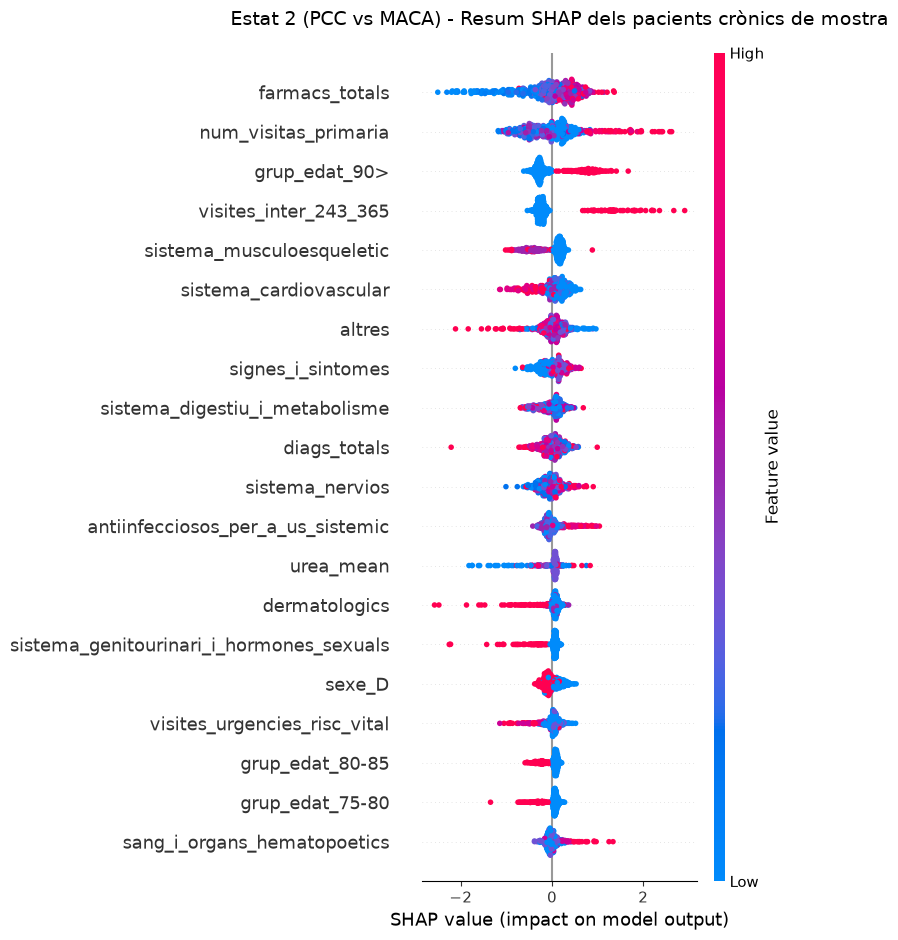

In [9]:
# Gràfic de resum global (Beeswarm) de l'Estat 2 (PCC vs MACA)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_s2_maca, X_sample_c, show=False)
plt.title("Estat 2 (PCC vs MACA) - Resum SHAP dels pacients crònics de mostra", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Explicació local d'un pacient crònic de la mostra:


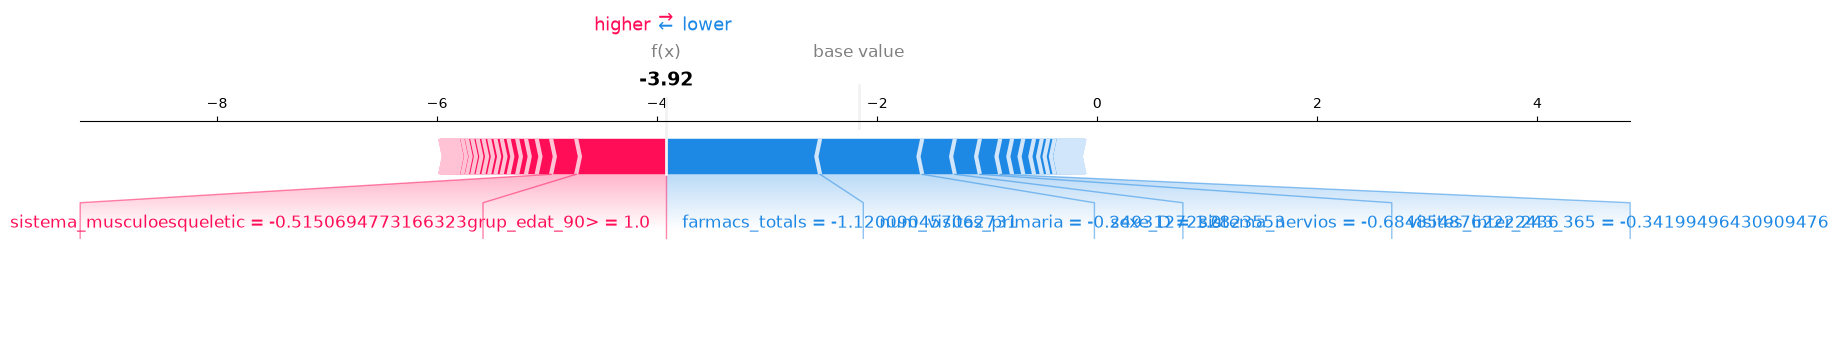

In [10]:
# Explicació local d'un pacient crònic (Force Plot)
print("Explicació local d'un pacient crònic de la mostra:")
shap.force_plot(
    explainer_s2.expected_value,
    shap_values_s2_maca[0],
    X_sample_c.iloc[0],
    matplotlib=True
)
plt.show()